In [6]:
from importlib.metadata import version

print(version("matplotlib"))
print(version("torch"))
print(version("tiktoken"))

3.10.9
2.11.0
0.12.0


In [12]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, 
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12, 
    "n_layers": 12,
    "drop_rate": 0.1, 
    "qkv_bias": False, 
}

In [13]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(*[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias = False)
    
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device = in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    def forward(self, x):
        return x
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps = 1e-5):
        super().__init__()
    
    def forward(self,x):
        return x


In [16]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim = 0)

print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [17]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

#logits is just last layer
logits = model(batch)
print(logits.shape)
print(logits)


torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


In [20]:
#Small Layer Normalization Test

torch.manual_seed(123)

batch_example = torch.randn(2,5)

layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)
print(out)

mean = out.mean(dim = -1, keepdim = True)
variance = out.var(dim = -1, keepdim = True)
print(f"mean: {mean}")
print(f"variance: {variance}")

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
mean: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
variance: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [23]:
out_norm = (out-mean)/torch.sqrt(variance)
print(f"normalized: {out_norm}")

mean = out_norm.mean(dim = -1, keepdim = True)
variance = out_norm.var(dim = -1, keepdim = True)
print(f"Mean: {mean}")
print(f"Variance: {variance}")

torch.set_printoptions(sci_mode = False)
print(mean)
print(variance)

normalized: tensor([[ 2.2595e-01,  3.4695e-01,  5.9605e-08,  2.2160e-01,  5.9605e-08,
          5.9605e-08],
        [ 2.1328e-01,  2.3942e-01, -1.9868e-08,  5.1984e-01,  3.2975e-01,
         -1.9868e-08]], grad_fn=<DivBackward0>)
Mean: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)
tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5

        #Scale and Shift Weights in Layer Normalization are used to adjust the normalized output
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        mean = x.mean(dim = -1, keepdim = True)
        var = x.var(dim = -1, keepdim = True, unbiased = False)
        norm_x = (x-mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [25]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+0.044715 * torch.pow(x,3))))

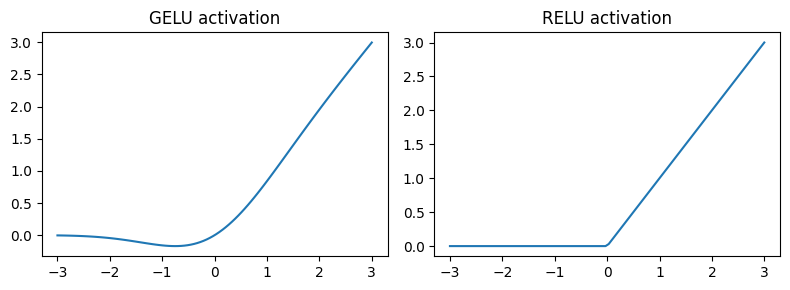

In [33]:
#Checking GELU vs ReLU

import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3,3,100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize = (8,3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "RELU"]), 1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f"{label} activation")
    plt.grid = True

plt.tight_layout()
plt.show()




In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        #Linear Layer, GELU, Linear Layer
        self.layers = nn.Sequential(nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), GELU(), nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),)
    
    def forward(self, x):
        return self.layers(x)

In [36]:
#print(GPT_CONFIG_124M["emb_dim"])

In [37]:
ffn = FeedForward(GPT_CONFIG_124M)

x = torch.rand(2,3,768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


In [38]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_Sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
        ])
    
    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
        
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        
        return x



def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward() #backpropogation


    for name, parameter in model.named_parameters():
        if 'weight' in name:
            print(f"{name} gradient = {parameter.grad.abs().mean().item()}")

In [42]:
layer_sizes = [3,3,3,3,3,1]

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut = False)
print_gradients(model_without_shortcut, sample_input)

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut = True)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight gradient = 0.00020173587836325169
layers.1.0.weight gradient = 0.0001201116101583466
layers.2.0.weight gradient = 0.0007152041071094573
layers.3.0.weight gradient = 0.0013988735154271126
layers.4.0.weight gradient = 0.005049645435065031
layers.0.0.weight gradient = 0.22169791162014008
layers.1.0.weight gradient = 0.20694106817245483
layers.2.0.weight gradient = 0.32896995544433594
layers.3.0.weight gradient = 0.2665732204914093
layers.4.0.weight gradient = 1.3258540630340576


In [ ]:
from model import MultiHeadAttention